In [1]:
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt

import torch

In [2]:
# We start with loading the .ssm data in this cell to keep the data loaded in the following
def load_full_dataset(dataset='Train'):
    # 1) Path Definition
    # base directory for the chosen dataset
    base_path = Path('../data/Challenge-ABC') / dataset
    if not base_path.exists(): # verification
        print(f"Error: Dataset folder {base_path} not found, check 'dataset' argument.")
        return None
    ssm_dir = base_path / 'SSM_Challenge-ABC'
    lb_dir = base_path / 'lb'

    X_list = []
    y_list = []

    ssm_files = list(ssm_dir.glob('*.ssm'))
    total_files = len(ssm_files)

    for i, ssm_file in enumerate(ssm_files, 1):
        file_id = ssm_file.stem
        lb_file = lb_dir / f"{file_id}.lb"

        # check that the labels file exists
        if not lb_file.exists():
            print(f"Error: Didn't find labels file for {file_id}.ply -> ignored.")
            continue

        features = np.loadtxt(ssm_file, skiprows=5, dtype='float32').reshape(-1, 20, 16)
        labels = np.loadtxt(lb_file, dtype='int')

        if len(labels) == len(features):
            X_list.append(features)
            y_list.append(labels)
        else:
            print(f"Error: Dimension error for {file_id} -> ignored.")

        if i % 20 == 0:
            print(f"Loading : {i}/{total_files} files...")

    X = np.vstack(X_list)
    y = np.concatenate(y_list)    
    
    return X, y


X_train, y_train, X_val, y_val = None, None, None, None

# save the datasets in a .npz file for faster loading in the future
npz_file = Path("../data/Challenge-ABC/datasets.npz")
if npz_file.exists():
    print("Loading datasets from .npz file...")
    data = np.load(npz_file)
    X_train, y_train = data['X_train'], data['y_train']
    X_val, y_val = data['X_val'], data['y_val']
else:
    print("Loading datasets from .ssm and .lb files...")
    print("Train dataset loading...")
    X_train, y_train = load_full_dataset('Train')
    print("\nValidation dataset loading...")
    X_val, y_val = load_full_dataset('Validation')
    np.savez(npz_file, X_train=X_train, y_train=y_train, X_val=X_val, y_val=y_val)
    print("npz file saved for future use.")

print(f"X_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"X_val shape: {X_val.shape}")
print(f"y_val shape: {y_val.shape}")

Loading datasets from .npz file...
X_train shape: (3174768, 20, 16)
y_train shape: (3174768,)
X_val shape: (690211, 20, 16)
y_val shape: (690211,)


In [3]:
print(f"X_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"X_val shape: {X_val.shape}")
print(f"y_val shape: {y_val.shape}")

print(type(X_train))
print(type(y_train))
print(type(X_val))
print(type(y_val))

# Transform numpy's arrays to torch tensors:
X_train = torch.tensor(X_train).to(torch.float)
y_train = torch.tensor(y_train)
X_val = torch.tensor(X_val).to(torch.float)
y_val = torch.tensor(y_val)

print(X_train.shape, y_train.shape)
print(X_val.shape, y_val.shape)

X_train shape: (3174768, 20, 16)
y_train shape: (3174768,)
X_val shape: (690211, 20, 16)
y_val shape: (690211,)
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
torch.Size([3174768, 20, 16]) torch.Size([3174768])
torch.Size([690211, 20, 16]) torch.Size([690211])


Beginning of the analysis...

---  Variance Analysis: 20 Descriptors (Mean aggregated) ---
Top 5 highest variances:
  1. Desc_20 : 5.58709e+04
  2. Desc_19 : 3.81319e+03
  3. Desc_2 : 5.44781e+02
  4. Desc_7 : 5.44780e+02
  5. Desc_5 : 5.43765e+02

Bottom 5 lowest variances:
  5. Desc_18 : 4.43865e-02
  4. Desc_13 : 9.98748e+00
  3. Desc_8 : 1.47593e+01
  2. Desc_3 : 1.47611e+01
  1. Desc_16 : 5.14068e+02


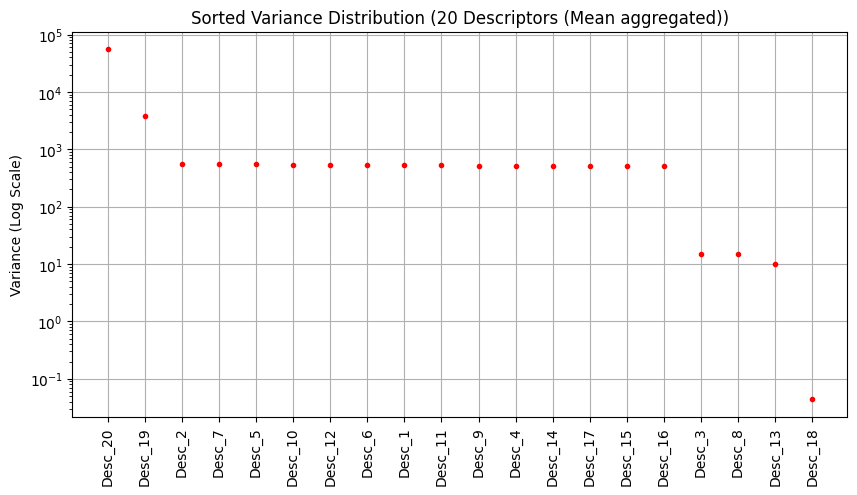


---  Variance Analysis: 320 Features ---
Top 5 highest variances:
  1. Feat_309 : 3.97219e+06
  2. Feat_310 : 1.82094e+06
  3. Feat_311 : 2.99711e+05
  4. Feat_289 : 2.59798e+05
  5. Feat_290 : 1.73140e+05

Bottom 5 lowest variances:
  5. Feat_38 : 1.53458e-03
  4. Feat_58 : 1.53458e-03
  3. Feat_78 : 1.53458e-03
  2. Feat_98 : 1.53458e-03
  1. Feat_118 : 1.53458e-03


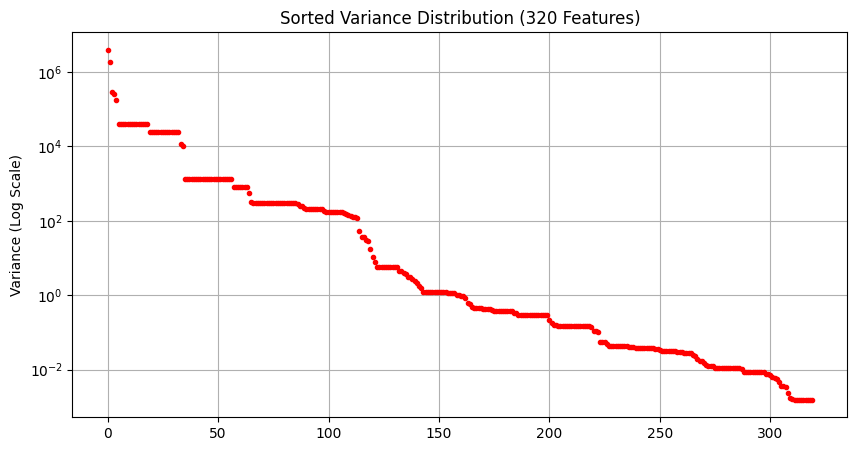

In [4]:
def analyze_variance(X, opt='desc'):
    if opt == 'desc':
        X_target = X.view(X.size(0), 20, 16).mean(dim=2)
        names = [f"Desc_{i+1}" for i in range(20)]
        title = "20 Descriptors (Mean aggregated)"
    elif opt == 'flat':
        X_target = X.view(X.size(0), -1)
        names = [f"Feat_{i+1}" for i in range(320)]
        title = "320 Features"
    else:
        raise ValueError("opt must be 'desc' or 'flat'")

    # var = std^2
    variances = (X_target.std(dim=0) ** 2).cpu().numpy()

    # sort by descending variance
    sorted_indices = np.argsort(variances)[::-1]
    sorted_vars = variances[sorted_indices]
    sorted_names = [names[i] for i in sorted_indices]

    # --- Console Display ---
    print(f"\n---  Variance Analysis: {title} ---")
    print("Top 5 highest variances:")
    for i in range(5):
        print(f"  {i+1}. {sorted_names[i]} : {sorted_vars[i]:.5e}")

    print("\nBottom 5 lowest variances:")
    for i in range(1, 6):
        # we take the 5 last elements of the array
        print(f"  {5-i+1}. {sorted_names[-i]} : {sorted_vars[-i]:.5e}")

    # --- Graphical Display ---
    plt.figure(figsize=(10, 5))
    plt.plot(sorted_vars, marker='.', linestyle='none', color='r')
    if opt == 'desc':
        plt.xticks(range(len(sorted_vars)), sorted_names, rotation=90)
    plt.title(f"Sorted Variance Distribution ({title})")
    plt.ylabel("Variance (Log Scale)")
    plt.yscale('log') # log scale to enhance readability
    plt.grid(True, alpha=1)
    plt.show()


    return sorted_indices, sorted_vars

# Execution for the two cases
print("Beginning of the analysis...")
indices_desc, vars_desc = analyze_variance(X_train, opt='desc')
indices_flat, vars_flat = analyze_variance(X_train, opt='flat')

In [5]:
def normalize_data(X, opt='desc'):
    if opt == 'desc':
        # we make sure the shape is (N, 20, 16) for the descriptor-based normalization
        X_reshaped = X.view(X.size(0), 20, 16)
        
        # we compute the mean across the 16 value/scales for each of the 20 descriptors to get a (N, 20) shape
        X_target = X_reshaped.mean(dim=2)
        
    elif opt == 'flat':
        # we make sure the shape is (N, 320) for the flat normalization
        X_target = X.view(X.size(0), -1)
        
    else:
        raise ValueError("opt must be 'desc' or 'flat'")

    # compute mean and std for each feature over the points (dim=0)
    mean = X_target.mean(dim=0, keepdim=True)
    std = X_target.std(dim=0, keepdim=True) + 1e-8 # to avoid zero division
    
    # normalize
    X_normalized = (X_target - mean) / std
    
    return X_normalized


#print("Test option 'desc' :")
#X_norm_desc = normalize_data(X_train, opt='desc')
#print(f"Shape: {X_norm_desc.shape}")
#print(f"Mean (should be ~0) : {X_norm_desc.mean(dim=0)[0].item():.4f}")
#print(f"Std (should be ~1) : {X_norm_desc.std(dim=0)[0].item():.4f}")

#print("\nTest option 'flat' :")
#X_norm_flat = normalize_data(X_train, opt='flat')
#print(f"Shape: {X_norm_flat.shape}")
#print(f"Mean (should be ~0) : {X_norm_flat.mean(dim=0)[0].item():.4f}")
#print(f"Std (should be ~1) : {X_norm_flat.std(dim=0)[0].item():.4f}")

In [6]:
def normalize_data_inplace(X, mean=None, std=None, opt='flat'):
    if opt == 'desc':
        X = X.view(X.size(0), 20, 16).mean(dim=2)
    elif opt == 'flat':
        X = X.view(X.size(0), -1)
    else:
        raise ValueError("opt must be 'desc' or 'flat'")

    mean = X.mean(dim=0, keepdim=True)
    std = X.std(dim=0, keepdim=True) + 1e-8
    
    # In-place normalization
    X.sub_(mean).div_(std)
    
    return X


print("Test option 'desc' :")
X_norm_desc = normalize_data_inplace(X_train, opt='desc')
print(f"Shape: {X_norm_desc.shape}")
print(f"Mean (should be ~0) : {X_norm_desc.mean(dim=0)[0].item():.4f}")
print(f"Std (should be ~1) : {X_norm_desc.std(dim=0)[0].item():.4f}")

print("\nTest option 'flat' :")
X_norm_flat = normalize_data_inplace(X_train, opt='flat')
print(f"Shape: {X_norm_flat.shape}")
print(f"Mean (should be ~0) : {X_norm_flat.mean(dim=0)[0].item():.4f}")
print(f"Std (should be ~1) : {X_norm_flat.std(dim=0)[0].item():.4f}")

Test option 'desc' :
Shape: torch.Size([3174768, 20])
Mean (should be ~0) : -0.0000
Std (should be ~1) : 1.0000

Test option 'flat' :
Shape: torch.Size([3174768, 320])
Mean (should be ~0) : -0.0000
Std (should be ~1) : 1.0000



--- Correlation Analysis ---
Compute Correlation Matrix (320 Features Correlation (Flat))...


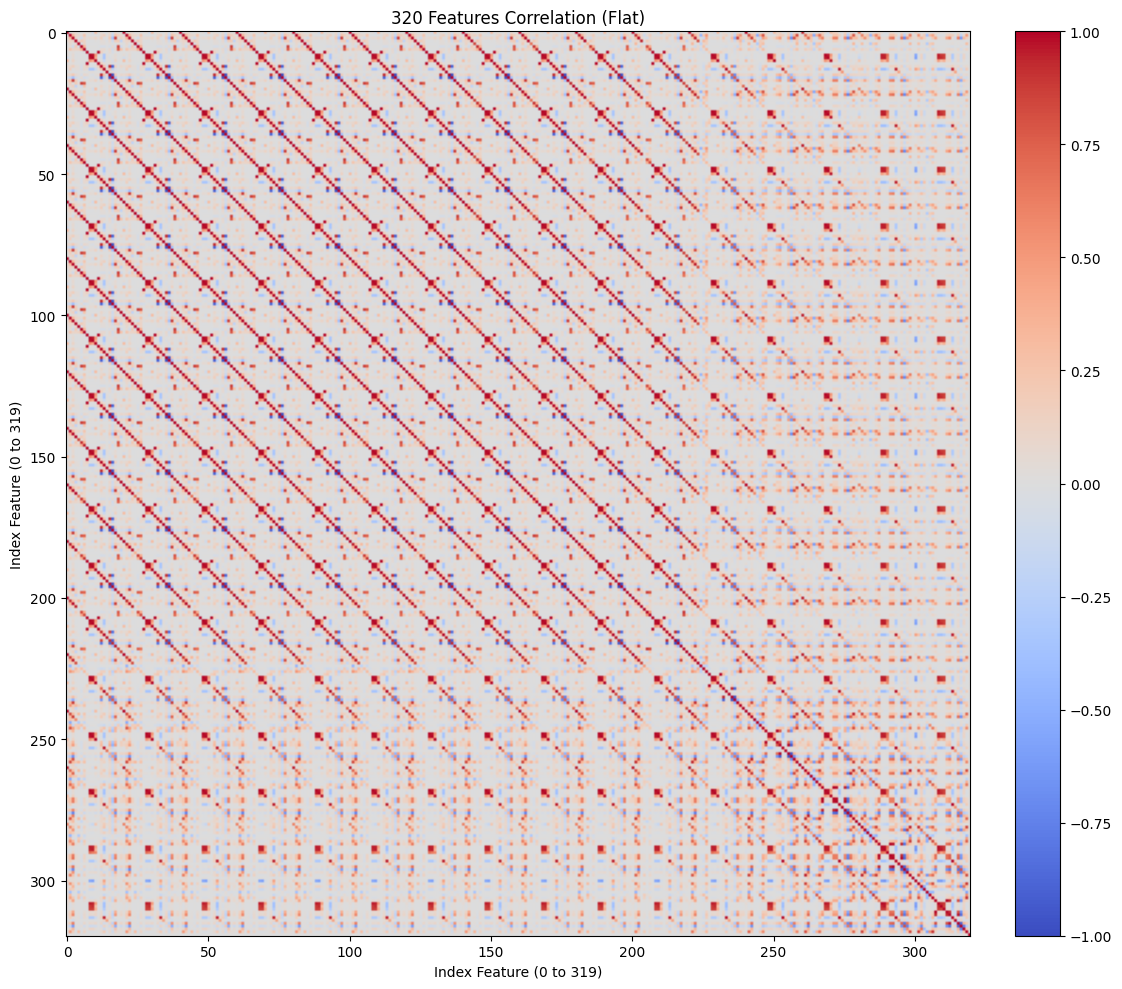

Compute Correlation Matrix (20 Descriptors Correlation (Mean aggregated))...


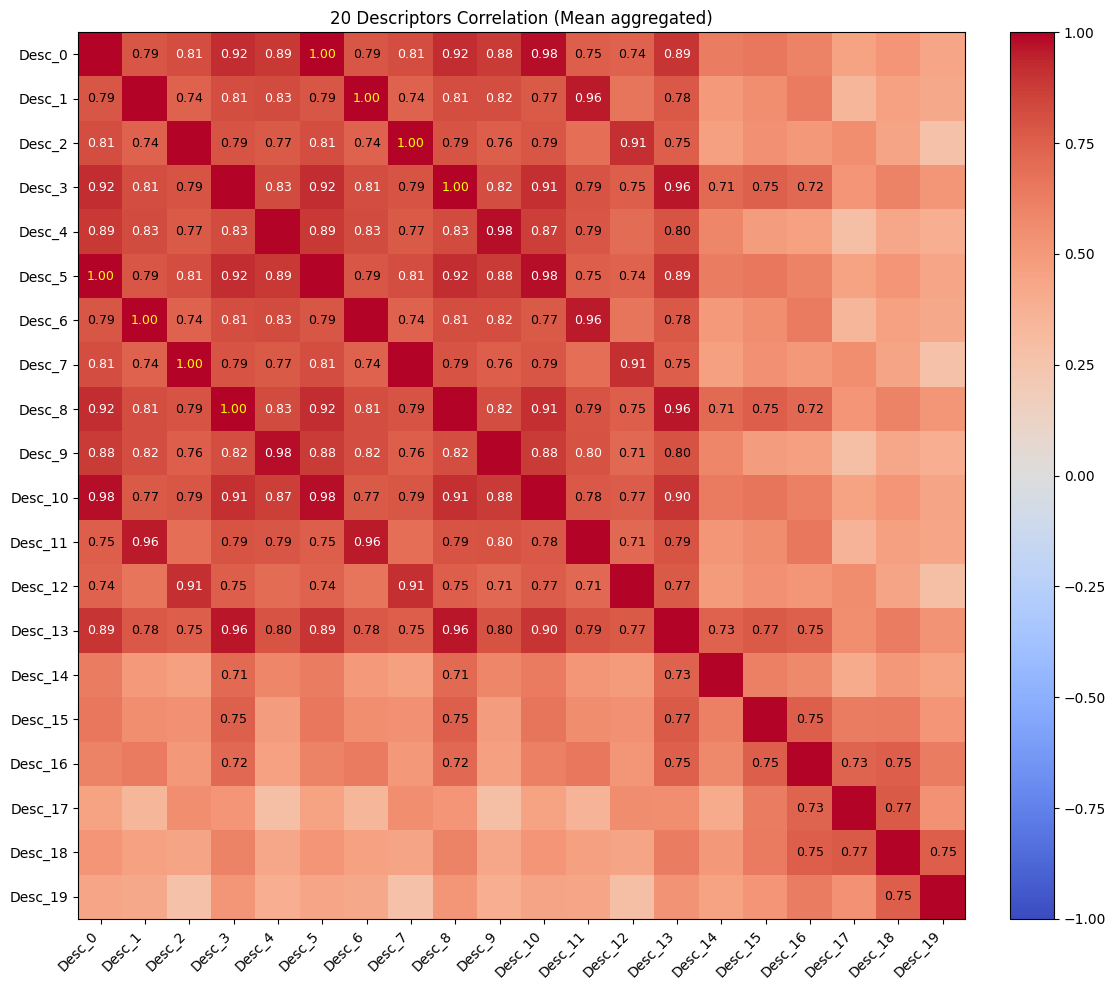

In [7]:
def analyze_correlation(X_norm, title="Correlation Matrix", labels=None):
    print(f"Compute Correlation Matrix ({title})...")

    # we extract the number of features
    _, F = X_norm.shape 

    # we use pytorch's native correlation coef function for efficiency
    corr_matrix = torch.corrcoef(X_norm.T) # X_norm.T bcos torch.corrcoef needs shape of variables and observations but we have them in the opposite order (N, F) instead of (F, N)
    
    # go back to cpu for matplotlib
    corr_matrix_cpu = corr_matrix.cpu().numpy()

    # Display
    plt.figure(figsize=(12, 10))
    im = plt.imshow(corr_matrix_cpu, cmap='coolwarm', vmin=-1, vmax=1)
    plt.colorbar(im, fraction=0.046, pad=0.04)
    plt.title(title)

    # labels and axes
    if labels is not None and F == len(labels):
        plt.xticks(np.arange(F), labels, rotation=45, ha='right')
        plt.yticks(np.arange(F), labels)
        
        # we write the coef if the value is > 0.7
        for i in range(F):
            for j in range(F):
                val = corr_matrix_cpu[i, j]
                if abs(val) > 0.7 and i != j:
                    # better visibility for very high correlations
                    if abs(val) >= 0.995:
                        color = "yellow"
                    elif abs(val) > 0.8:
                        color = "white"
                    else:
                        color = "black"
                    plt.text(j, i, f"{val:.2f}", ha="center", va="center", color=color, fontsize=9)
    else:
        # classic display for 320 features
        plt.xlabel(f"Index Feature (0 to {F-1})")
        plt.ylabel(f"Index Feature (0 to {F-1})")

    plt.tight_layout()
    plt.show()
    
    return corr_matrix_cpu


print("\n--- Correlation Analysis ---")

X_norm_flat = normalize_data(X_train, opt='flat') # we use normalize_data (not in-place version) to not permanently alter X_train in RAM
corr_matrix_flat = analyze_correlation(X_norm_flat, title="320 Features Correlation (Flat)")

# Free the copy to free up RAM
del X_norm_flat
torch.cuda.empty_cache()

# we still have X_train intact
X_norm_desc = normalize_data(X_train, opt='desc')
corr_matrix_desc = analyze_correlation(
    X_norm_desc, 
    title="20 Descriptors Correlation (Mean aggregated)", 
    labels=[f"Desc_{i}" for i in range(20)]
)

# clean up
del X_norm_desc
torch.cuda.empty_cache()

1. 320 Features Normalization...
2. Tensor Reshaping...
   -> New shape for the analysis : torch.Size([63495360, 16])
3. Scales Correlation Matrix (16x16)...


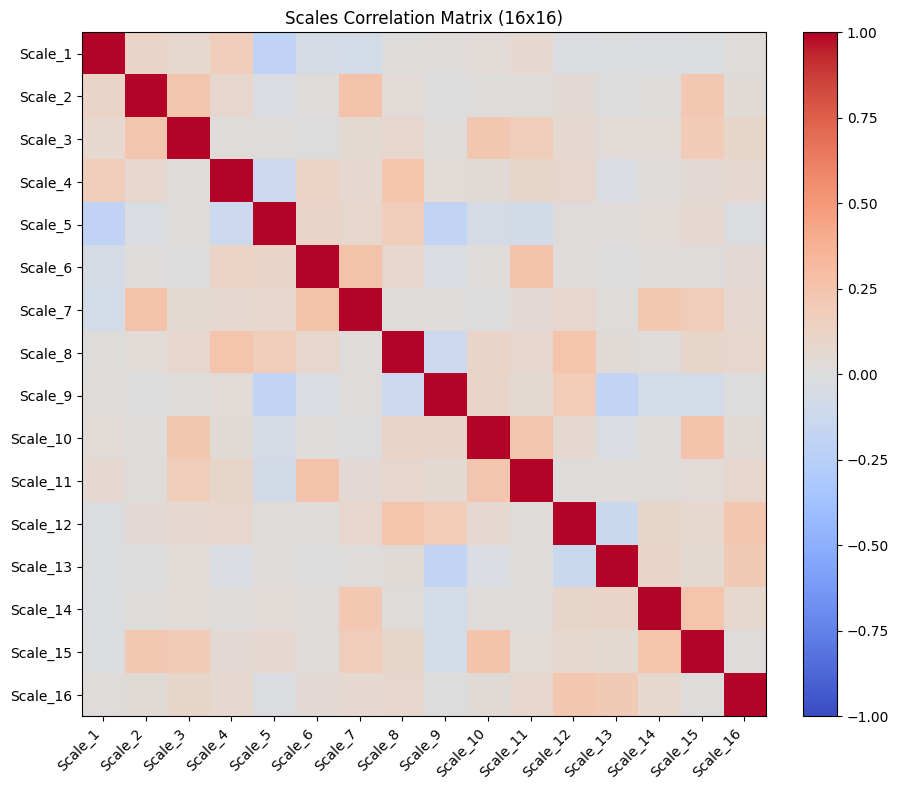

In [8]:
def analyze_scales_correlation(X_train_raw):
    print("1. 320 Features Normalization...")
    # we create a normalized copy of the original data (N, 320)
    X_norm_flat = normalize_data(X_train_raw, opt='flat')
    N = X_norm_flat.size(0)
    
    print("2. Tensor Reshaping...")
    # we go back to the original 3D shape
    X_3D = X_norm_flat.view(N, 20, 16)
    
    # we merge the points axis and the descriptors axis
    # the tensor becomes (N * 20, 16)
    X_scales = X_3D.view(-1, 16)
    
    print(f"   -> New shape for the analysis : {X_scales.shape}")
    print("3. Scales Correlation Matrix (16x16)...")
    
    # torch.corrcoef needs (Variables, Observations), so X_scales.T
    corr_matrix = torch.corrcoef(X_scales.T)
    corr_matrix_cpu = corr_matrix.cpu().numpy()
    
    # Display
    plt.figure(figsize=(10, 8))
    im = plt.imshow(corr_matrix_cpu, cmap='coolwarm', vmin=-1, vmax=1)
    plt.colorbar(im, fraction=0.046, pad=0.04)
    plt.title("Scales Correlation Matrix (16x16)")
    
    # Labels for the 16 scales
    labels = [f"Scale_{i+1}" for i in range(16)]
    plt.xticks(np.arange(16), labels, rotation=45, ha='right')
    plt.yticks(np.arange(16), labels)
    
    # we write the coef if the value is > 0.7
    for i in range(16):
        for j in range(16):
            val = corr_matrix_cpu[i, j]
            if abs(val) > 0.7 and i != j:
                color = "yellow" if abs(val) >= 0.995 else ("white" if abs(val) > 0.9 else "black")
                plt.text(j, i, f"{val:.2f}", ha="center", va="center", color=color, fontsize=9)
                
    plt.tight_layout()
    plt.show()
    
    # free up RAM
    del X_norm_flat
    del X_3D
    del X_scales
    torch.cuda.empty_cache()
    
    return corr_matrix_cpu

corr_scales = analyze_scales_correlation(X_train)